In [1]:
%set_env CUDA_VISIBLE_DEVICES=1
# %load_ext cudf.pandas
import pandas as pd

# from eval_vlm.datasets_zoo.registry import list_datasets
from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = [
    # SigLIP 1.0 - ViT variants
    "siglip_vitB16",
    "siglip_vitB16_256",
    "siglip_vitB16_384",
    "siglip_vitB16_512",
    "siglip_vitL16",
    "siglip_vitL16_384",
    
    # SigLIP 1.0 - SO400M variants
    "siglip_so400_14",
    "siglip_so400_14_378",
    "siglip_so400_14_384",
    
    # SigLIP 2.0 - ViT variants
    "siglip2_vitB16",
    "siglip2_vitB16_256",
    "siglip2_vitB16_384",
    "siglip2_vitB16_512",
    "siglip2_vitB32_256",
    "siglip2_vitL16_256",
    "siglip2_vitL16_384",
    "siglip2_vitL16_512",
    
    # SigLIP 2.0 - SO400M variants
    "siglip2_so400_14",
    "siglip2_so400_14_378",
    "siglip2_so400_16_256",
    "siglip2_so400_16_384",
    "siglip2_so400_16_512"
]
benchmarks = list_benchmarks("all")
outputhandler = OutputHandler()

env: CUDA_VISIBLE_DEVICES=1


/home/haltahan6/anaconda3/envs/uni/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
    # use_cols=[
    #     "model_name",
    #     "benchmakr_name",
    #     "correctness",
    # ],
)

In [3]:
results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})

/tmp/ipykernel_2874497/2239926027.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


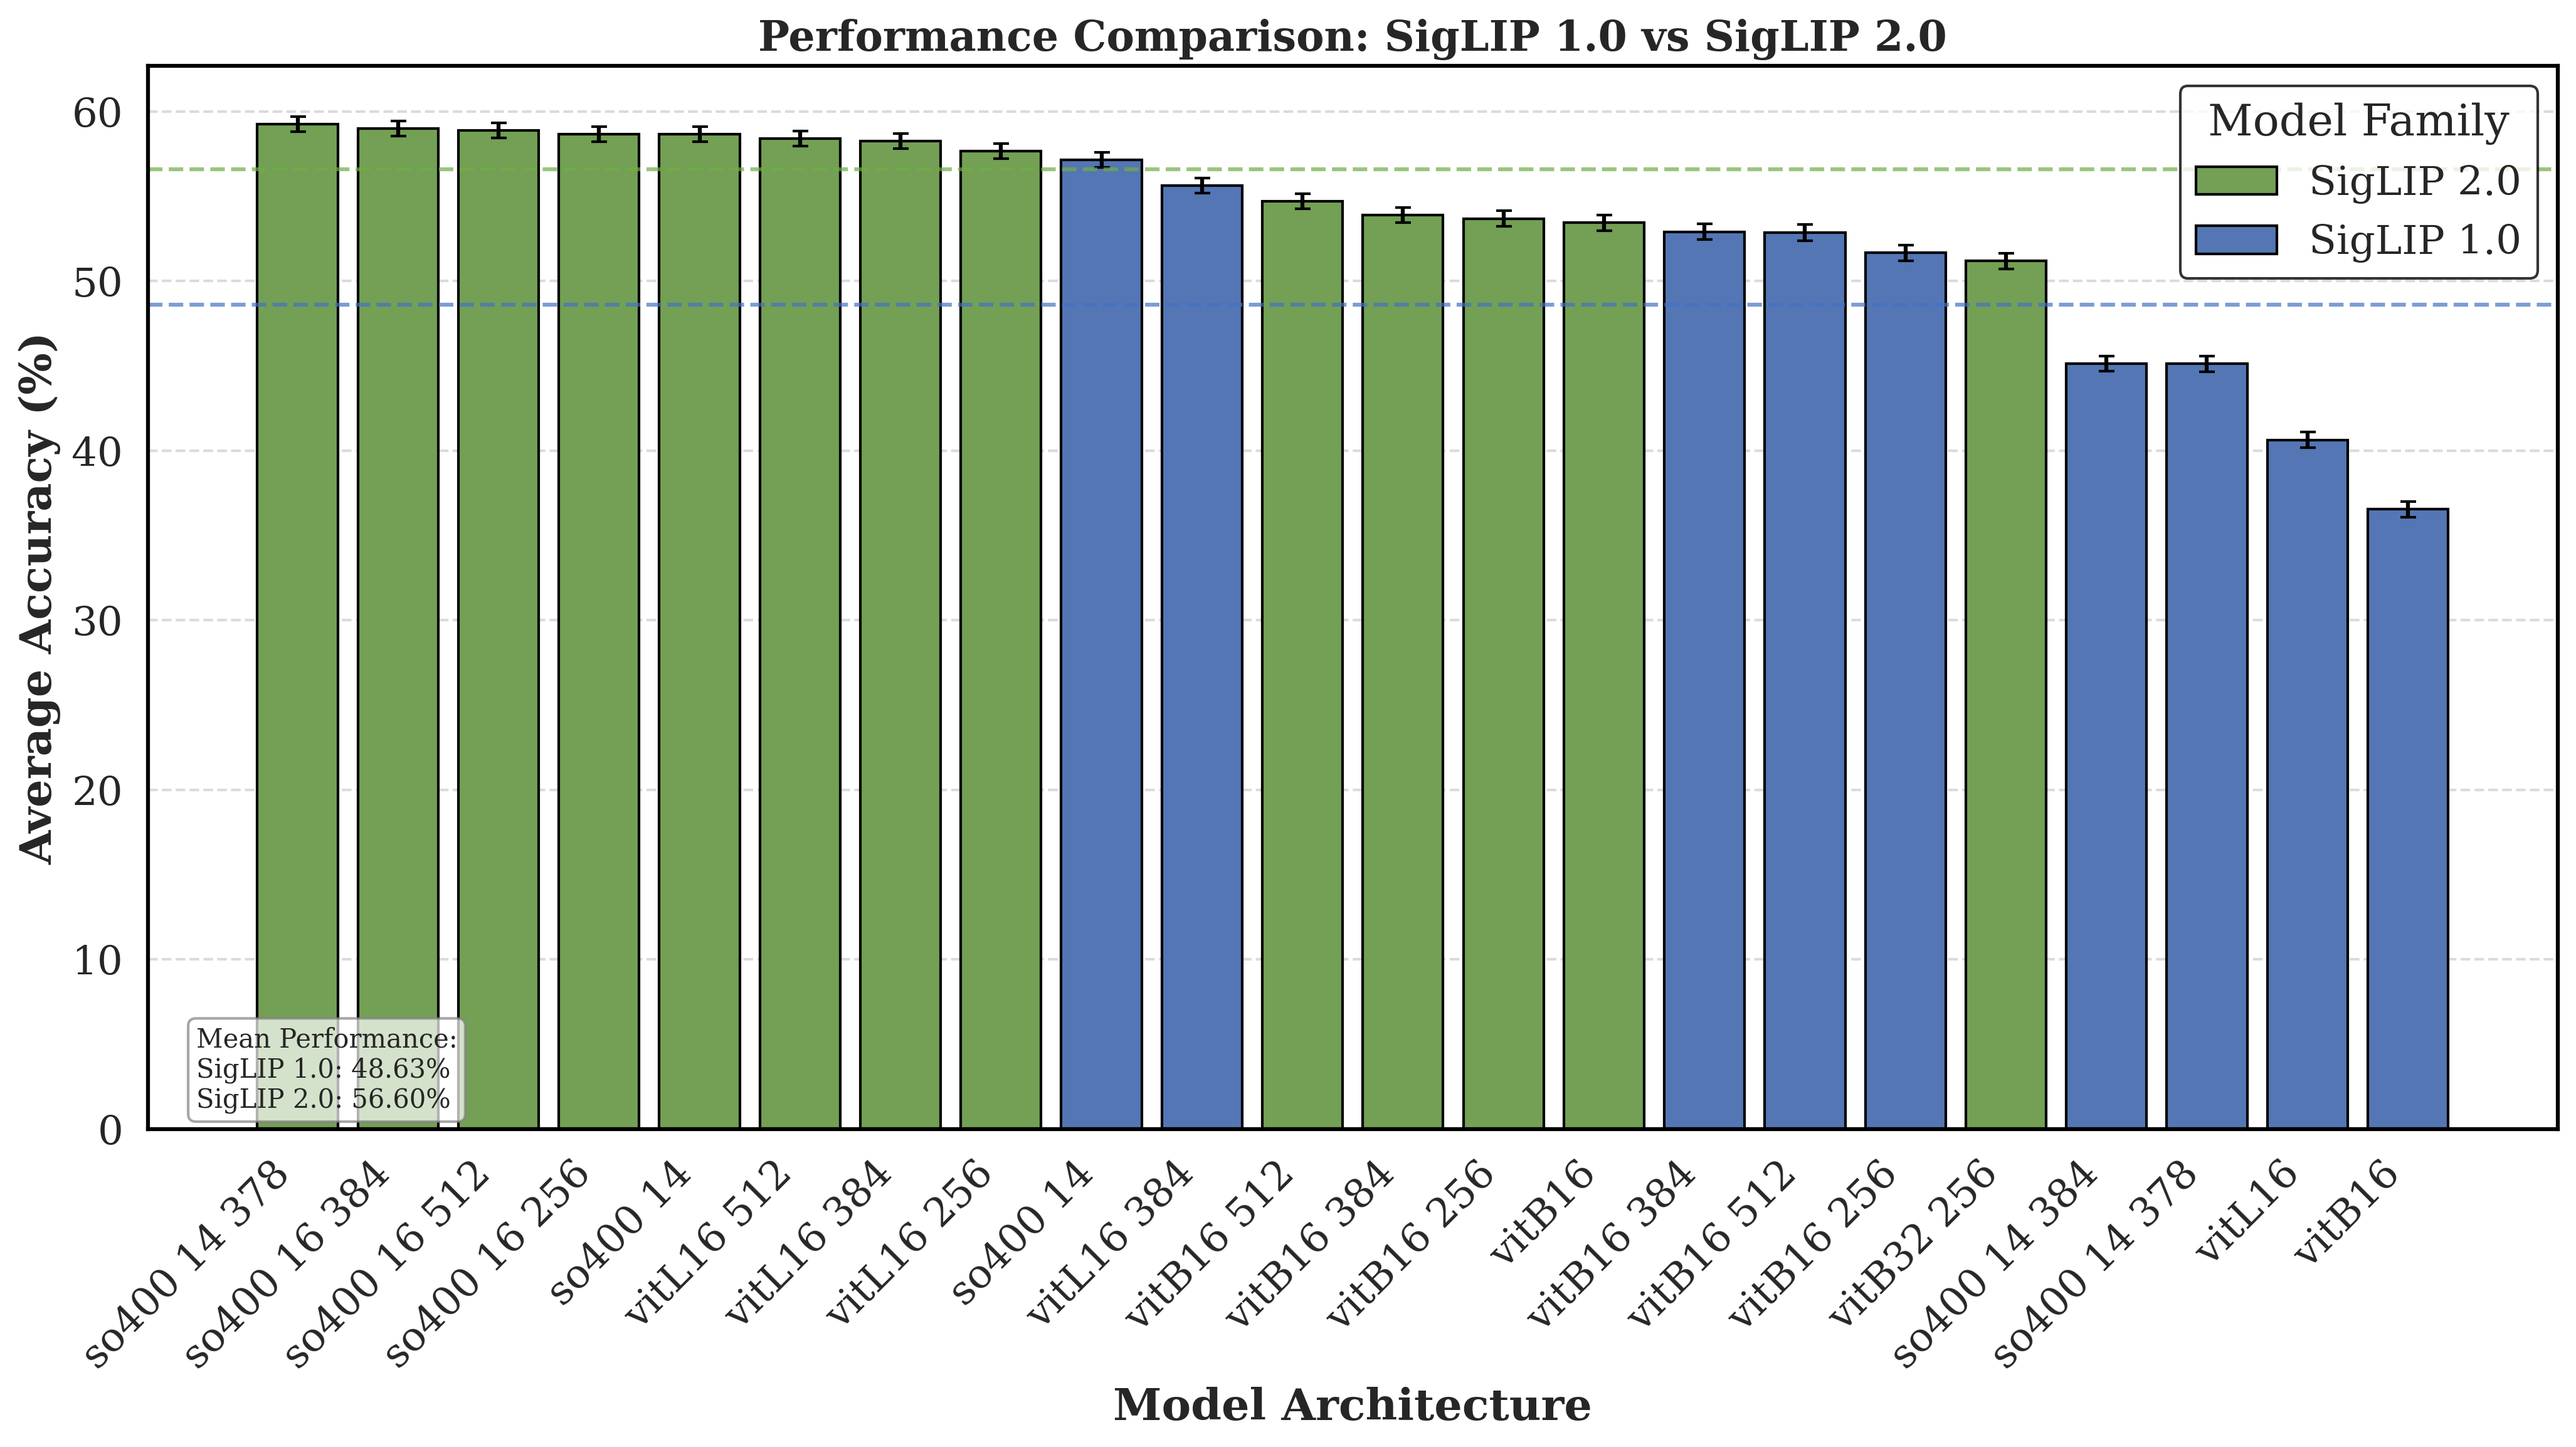

In [4]:
# Create dataframe with average performance across all benchmarks
df_mean = results.groupby(["model_name", "benchmark_name"]).correctness.mean()
df_sem = results.groupby(["model_name", "benchmark_name"]).correctness.sem()

# Calculate overall performance for each model
overall_performance = df_mean.reset_index().groupby("model_name").correctness.mean() * 100
overall_sem = df_sem.reset_index().groupby("model_name").correctness.mean() * 100

# Create model type column
model_data = pd.DataFrame({'model_name': overall_performance.index, 
                          'performance': overall_performance.values,
                          'sem': overall_sem.values})
model_data['type'] = model_data['model_name'].apply(lambda x: 'SigLIP 1.0' if not x.startswith('siglip2') else 'SigLIP 2.0')

# Sort by performance
sorted_models = model_data.sort_values('performance', ascending=False)

# Set up the plot with publication-ready styling
plt.figure(figsize=(14, 8), dpi=300)
sns.set(style="whitegrid", font_scale=1.4)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['axes.edgecolor'] = 'black'

# Create the barplot with error bars
ax = sns.barplot(
    x='model_name', 
    y='performance', 
    hue='type',
    data=sorted_models,
    palette={'SigLIP 1.0': '#4472C4', 'SigLIP 2.0': '#70AD47'},
    edgecolor='black',
    linewidth=1
)

# Add error bars
for i, row in enumerate(sorted_models.itertuples()):
    plt.errorbar(i, row.performance, yerr=row.sem, fmt='none', color='black', capsize=3, elinewidth=1.5)

# Customize the plot
plt.xticks(rotation=45, ha='right')
plt.xlabel('Model Architecture', fontweight='bold')
plt.ylabel('Average Accuracy (%)', fontweight='bold')
plt.title('Performance Comparison: SigLIP 1.0 vs SigLIP 2.0', fontweight='bold', fontsize=16)

# Add a horizontal line for the average performance of each model type
siglip1_avg = sorted_models[sorted_models['type'] == 'SigLIP 1.0']['performance'].mean()
siglip2_avg = sorted_models[sorted_models['type'] == 'SigLIP 2.0']['performance'].mean()
plt.axhline(y=siglip1_avg, color='#4472C4', linestyle='--', alpha=0.7, linewidth=1.5)
plt.axhline(y=siglip2_avg, color='#70AD47', linestyle='--', alpha=0.7, linewidth=1.5)

# Format x-axis labels
labels = [' '.join(x.split('_')[1:]) for x in sorted_models['model_name']]
ax.set_xticklabels(labels)

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Improve legend
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, title='Model Family', frameon=True, edgecolor='black')

# Add mean performance annotation
textstr = f"Mean Performance:\nSigLIP 1.0: {siglip1_avg:.2f}%\nSigLIP 2.0: {siglip2_avg:.2f}%"
props = dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='gray')
plt.annotate(textstr, xy=(0.02, 0.02), xycoords='axes fraction', bbox=props, fontsize=10)

plt.tight_layout()
plt.show()


/tmp/ipykernel_2874497/656941233.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')
/tmp/ipykernel_2874497/656941233.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')
/tmp/ipykernel_2874497/656941233.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')
/tmp/ipykernel_2874497/656941233.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')
/tmp/ipykernel_2874497/656941233.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of

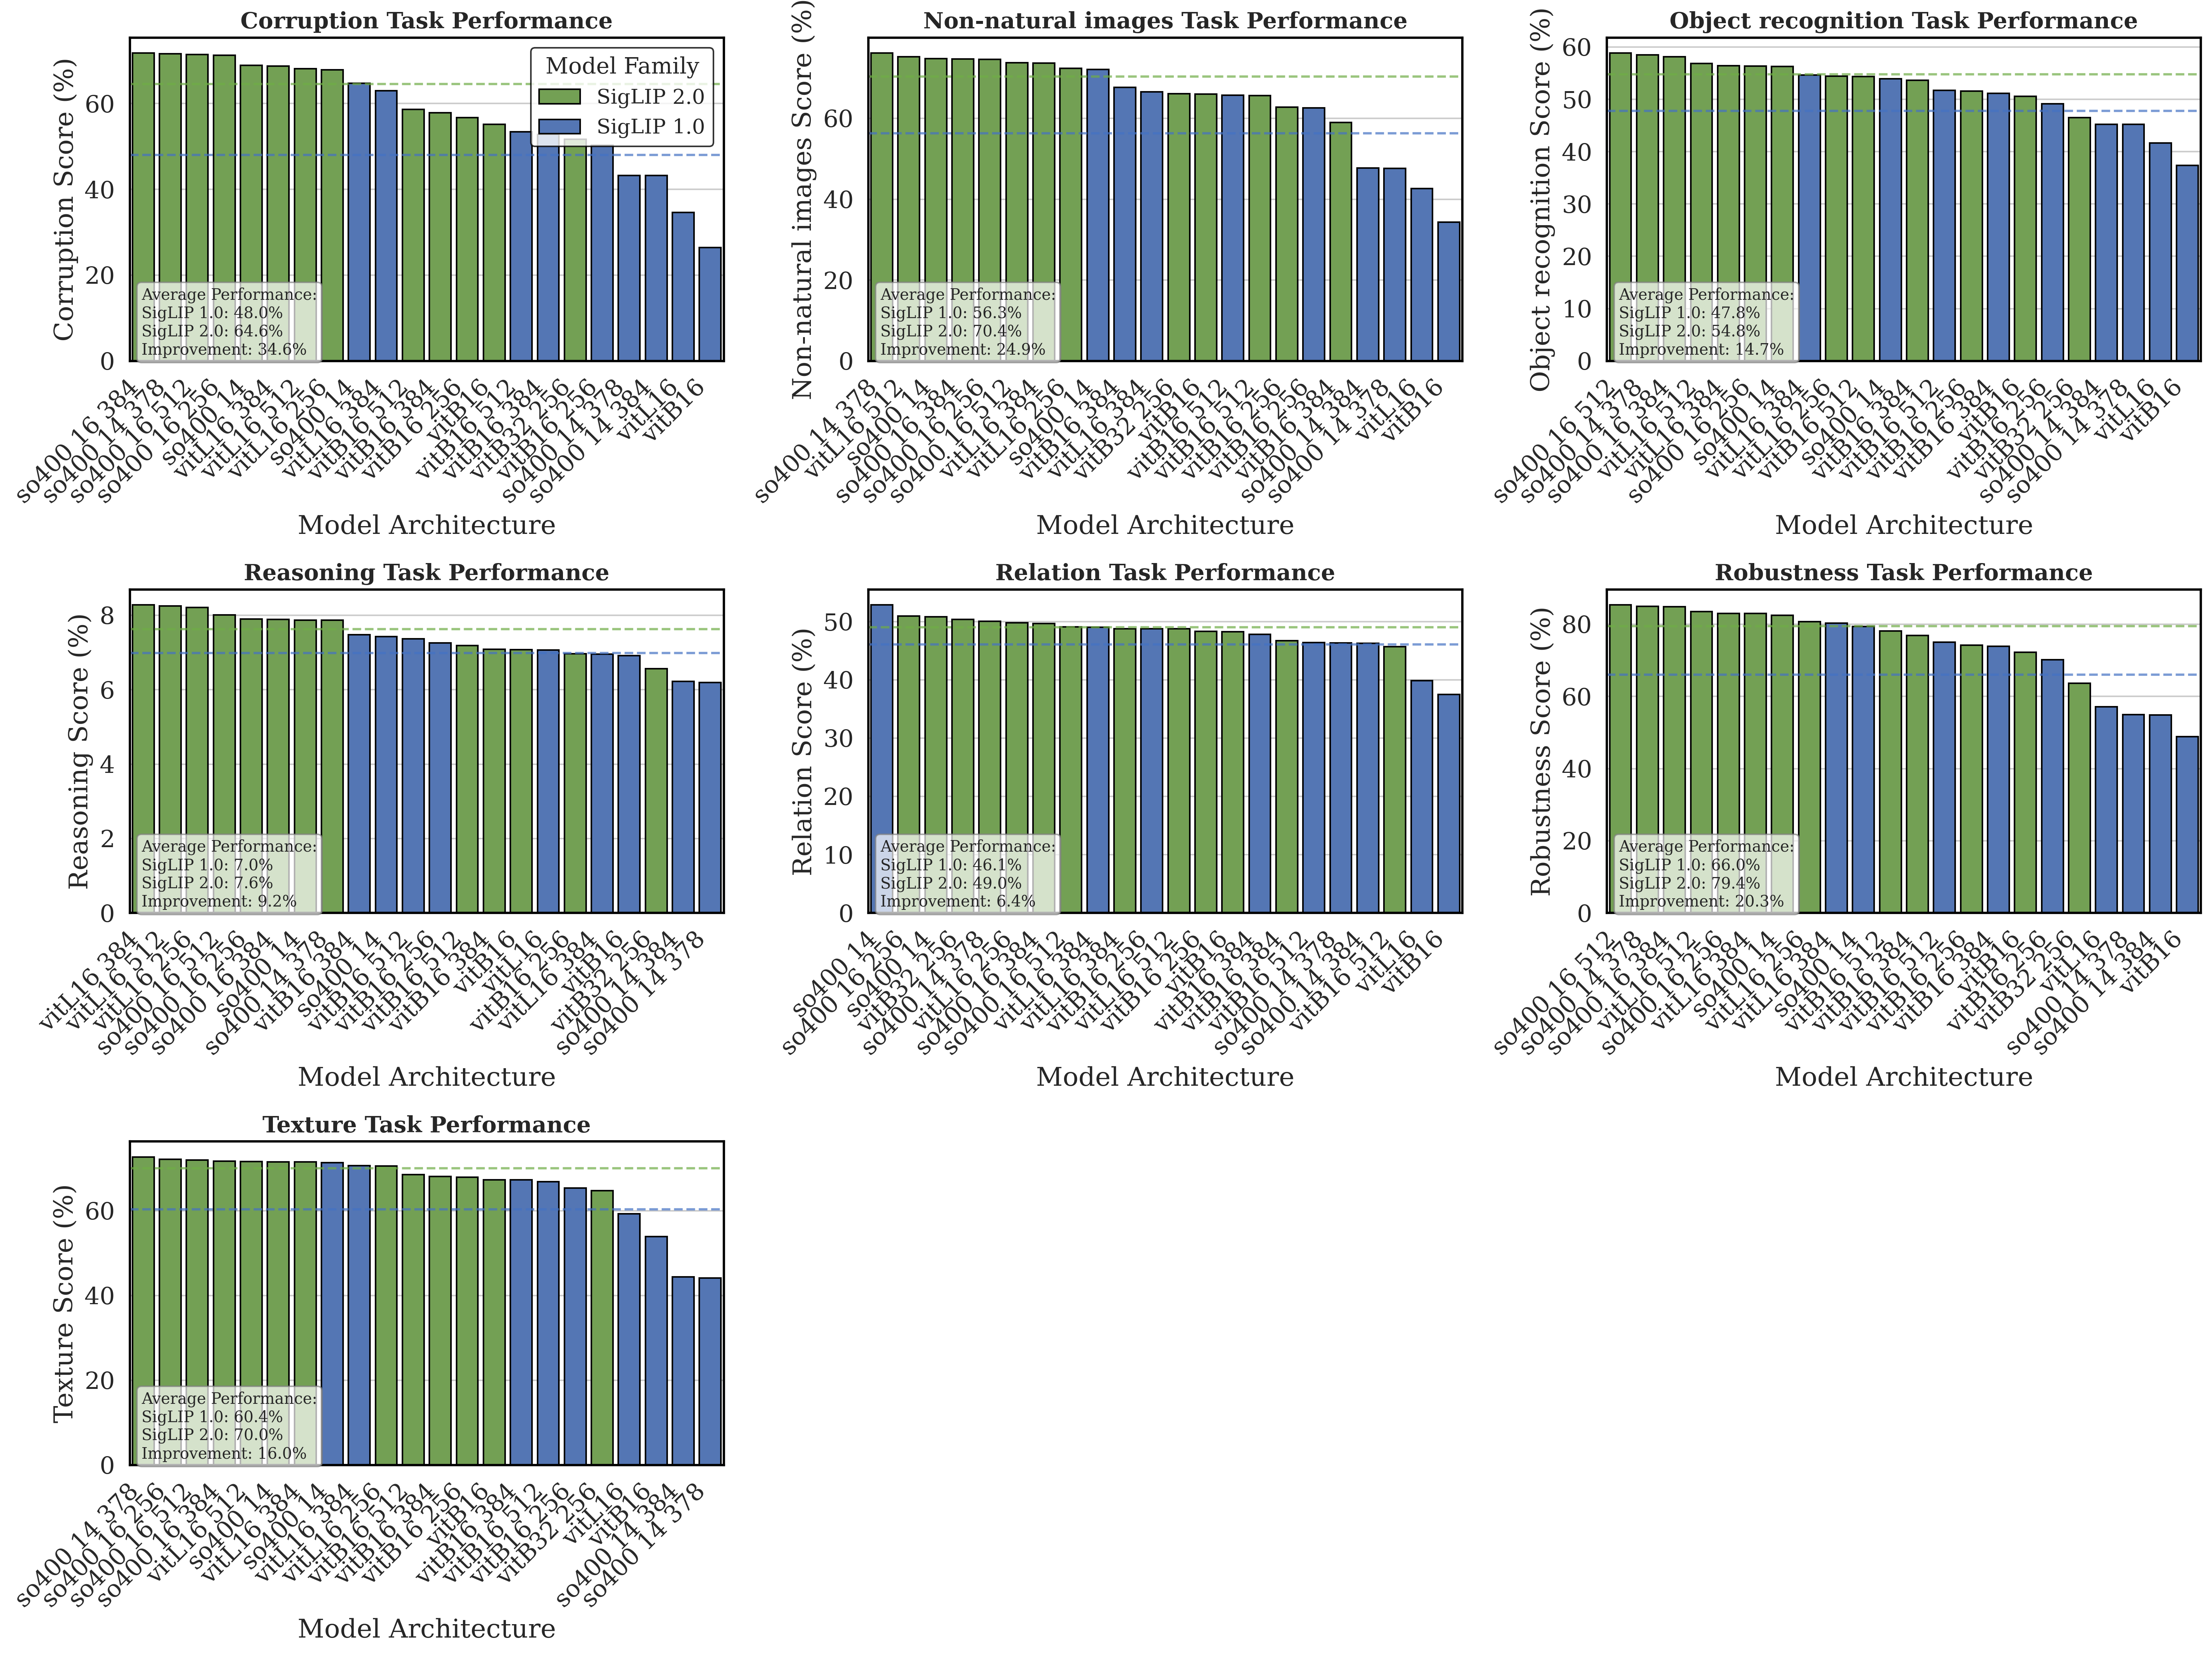

/tmp/ipykernel_2874497/656941233.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='benchmark_type', y='improvement', data=summary_data, palette=colors, edgecolor='black', linewidth=1)


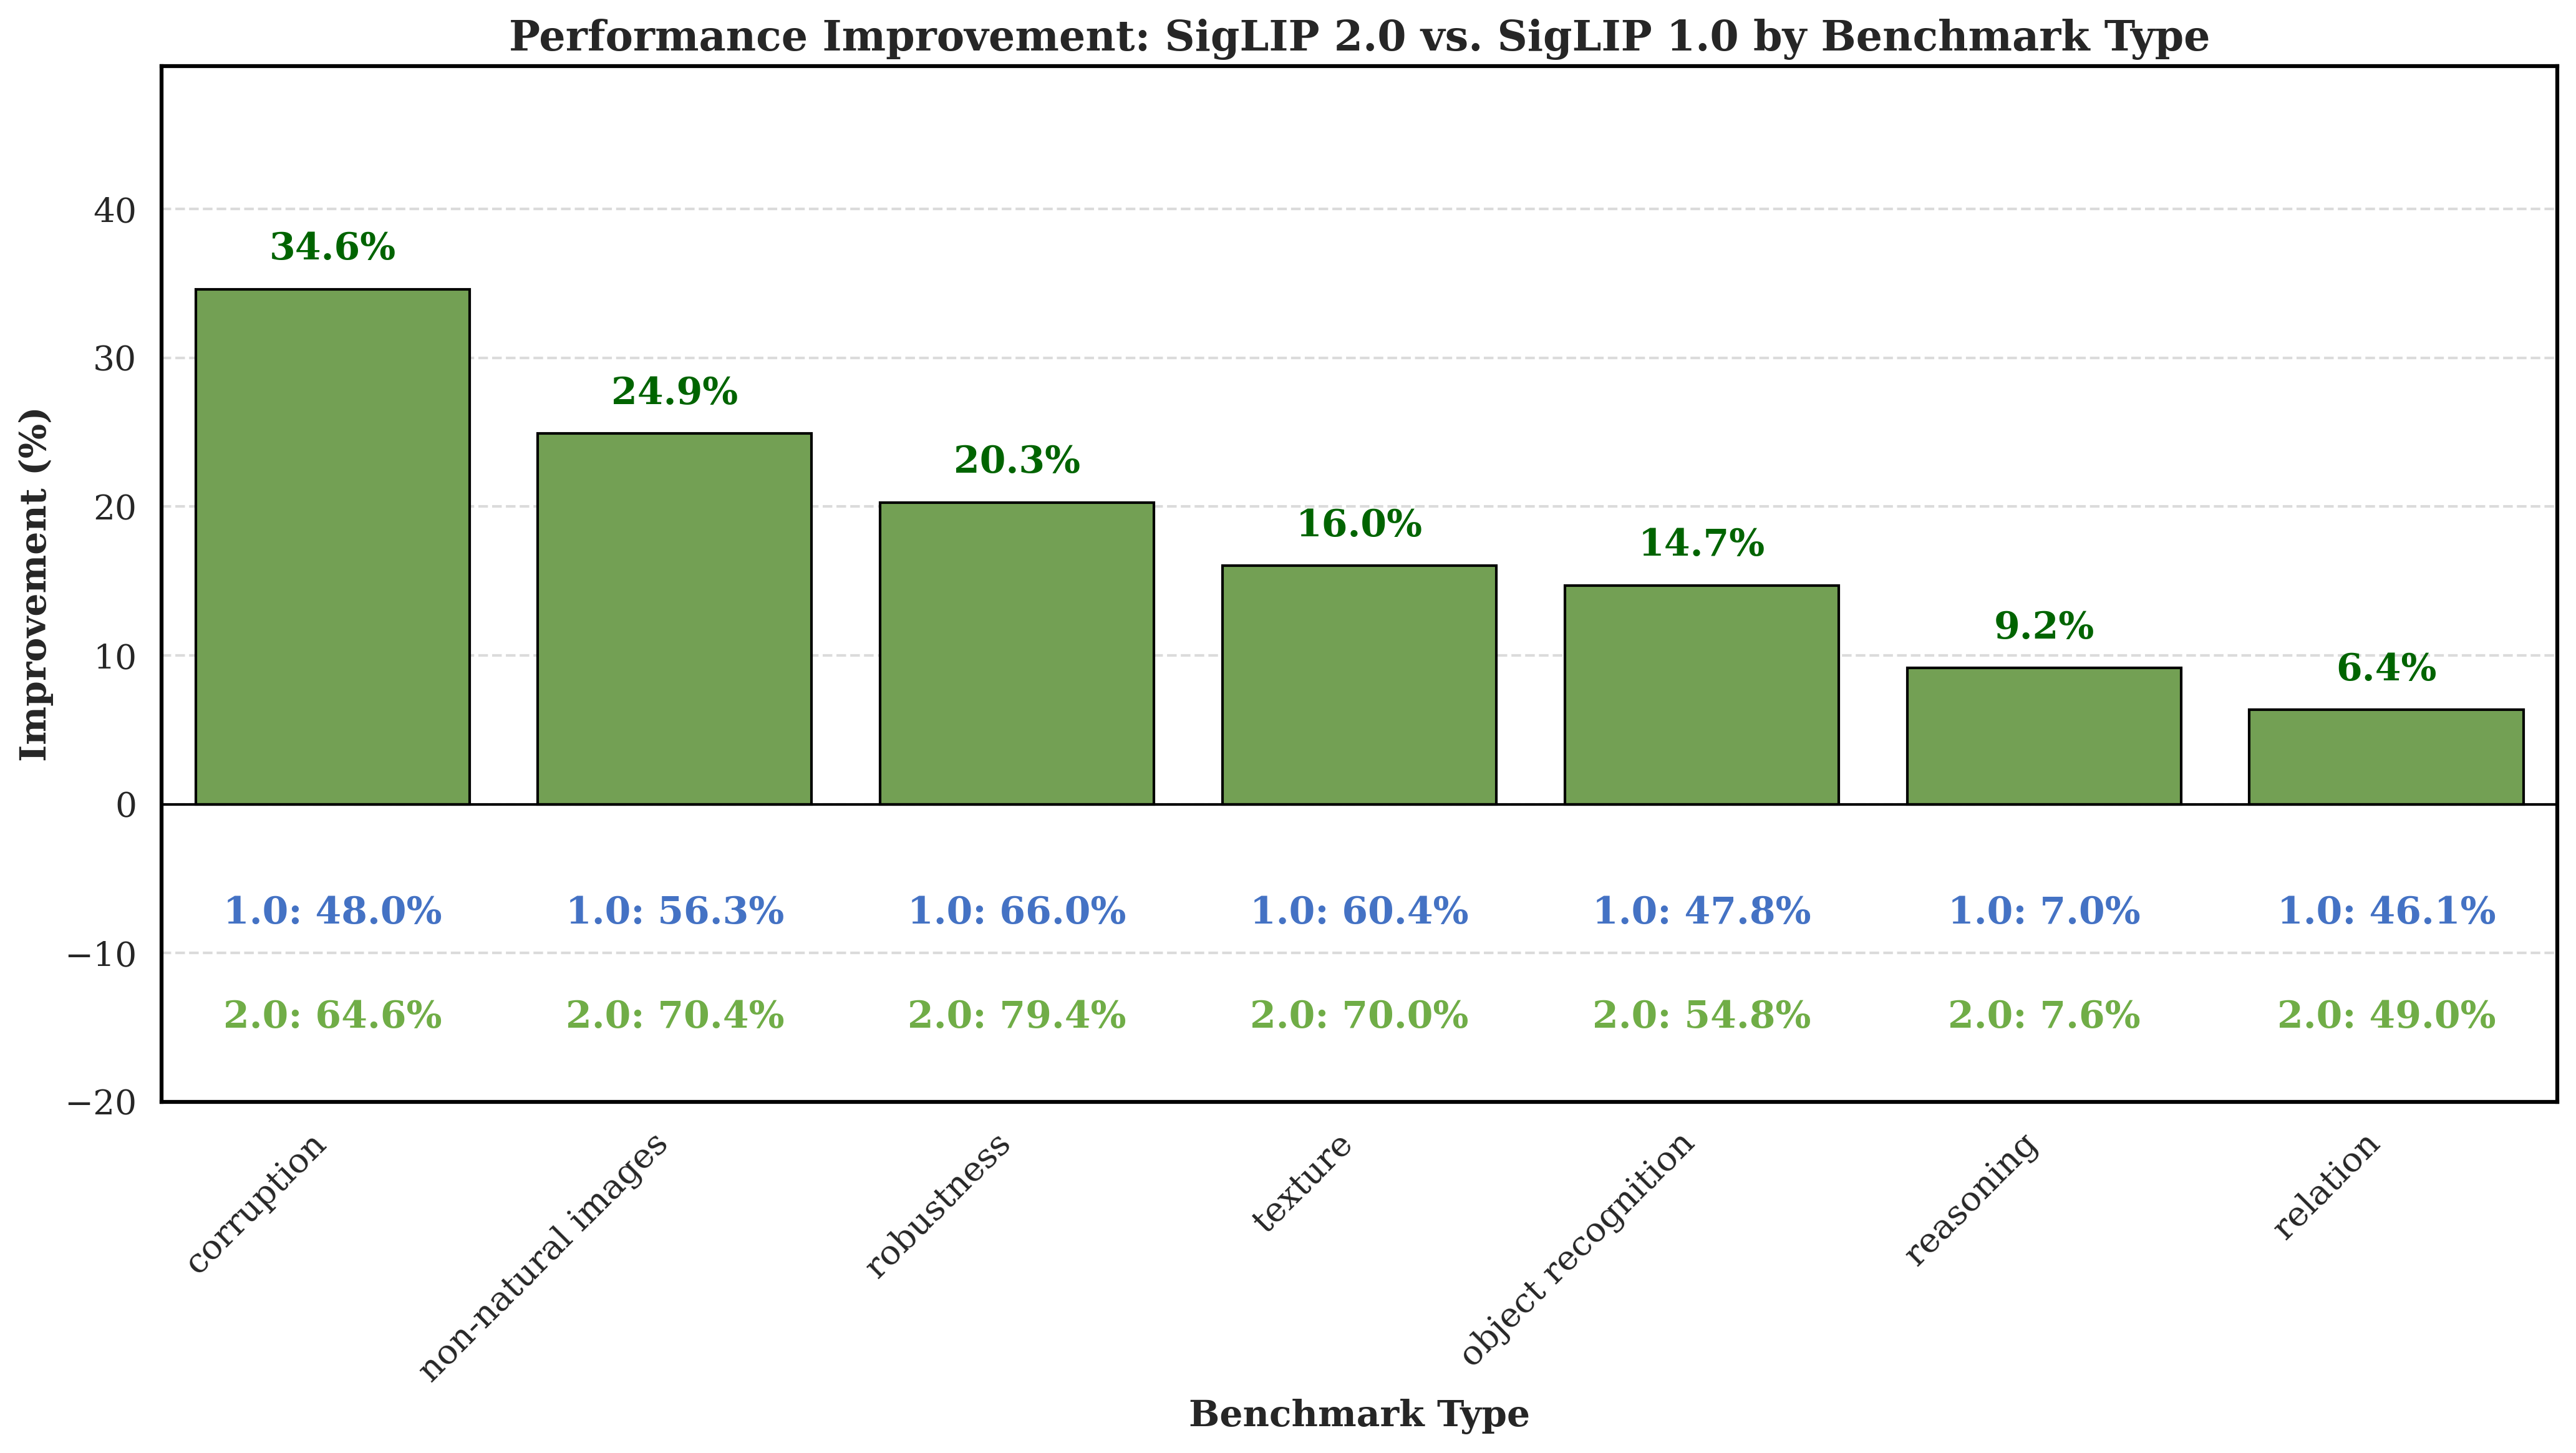

In [5]:
from unibench.common_utils.utils import get_benchmark_mappings
benchmark_mappings = get_benchmark_mappings("benchmark_type")
results["benchmark_type"] = results["benchmark_name"].map(benchmark_mappings)

# Get unique benchmark types
benchmark_types = results.benchmark_type.unique()
benchmark_types = sorted(benchmark_types)  # Sort them for consistent order

# Group results by model_name, benchmark_type and calculate mean performance
type_performance = results.groupby(["model_name", "benchmark_type"]).correctness.mean() * 100
type_sem = results.groupby(["model_name", "benchmark_type"]).correctness.sem() * 100

# Create a DataFrame with the performance data
performance_by_type = type_performance.reset_index().pivot(index='model_name', columns='benchmark_type', values='correctness')
performance_by_type = performance_by_type.reset_index()

# Add model type column
performance_by_type['type'] = performance_by_type['model_name'].apply(lambda x: 'SigLIP 1.0' if not x.startswith('siglip2') else 'SigLIP 2.0')

# Set up the figure with subplots - determine grid dimensions
import math
num_types = len(benchmark_types)
cols = 3  # Adjust as needed
rows = math.ceil(num_types / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows), dpi=300)
axes = axes.flatten()  # Flatten for easy indexing

# Set style
sns.set(style="whitegrid", font_scale=1.2)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['axes.edgecolor'] = 'black'

# Iterate through each benchmark type
for i, benchmark_type in enumerate(benchmark_types):
    # Skip if benchmark type is missing in the data
    if benchmark_type not in performance_by_type.columns:
        axes[i].axis('off')
        continue
    
    # Prepare data for this benchmark type
    data = performance_by_type[['model_name', benchmark_type, 'type']].copy()
    data.columns = ['model_name', 'performance', 'type']
    data = data.dropna()
    
    # Calculate averages for each type
    siglip1_avg = data[data['type'] == 'SigLIP 1.0']['performance'].mean()
    siglip2_avg = data[data['type'] == 'SigLIP 2.0']['performance'].mean()
    improvement = ((siglip2_avg - siglip1_avg) / siglip1_avg * 100) if siglip1_avg > 0 else 0
    
    # Sort data for this plot
    data = data.sort_values('performance', ascending=False)
    
    # Create barplot
    ax = axes[i]
    sns.barplot(
        x='model_name', 
        y='performance', 
        hue='type',
        data=data,
        palette={'SigLIP 1.0': '#4472C4', 'SigLIP 2.0': '#70AD47'},
        edgecolor='black',
        linewidth=1,
        ax=ax
    )
    
    # Customize this subplot
    ax.set_title(f'{benchmark_type.capitalize()} Task Performance', fontweight='bold')
    ax.set_xlabel('Model Architecture')
    ax.set_ylabel(f'{benchmark_type.capitalize()} Score (%)')
    
    # Format x-axis labels
    labels = [' '.join(x.split('_')[1:]) for x in data['model_name']]
    ax.set_xticklabels(labels, rotation=45, ha='right')
    
    # Add horizontal lines for average performance
    ax.axhline(y=siglip1_avg, color='#4472C4', linestyle='--', alpha=0.7, linewidth=1.5)
    ax.axhline(y=siglip2_avg, color='#70AD47', linestyle='--', alpha=0.7, linewidth=1.5)
    
    # Add improvement annotation
    textstr = f"Average Performance:\nSigLIP 1.0: {siglip1_avg:.1f}%\nSigLIP 2.0: {siglip2_avg:.1f}%\nImprovement: {improvement:.1f}%"
    props = dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='gray')
    ax.annotate(textstr, xy=(0.02, 0.02), xycoords='axes fraction', bbox=props, fontsize=10)
    
    # Legend for first plot only
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, title='Model Family', frameon=True, edgecolor='black')
    else:
        ax.get_legend().remove()  # Remove redundant legends

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Also create a summary plot showing the average improvement by benchmark type
plt.figure(figsize=(14, 8), dpi=300)

# Calculate average performance for each benchmark type and model family
avg_by_type = {}
for benchmark_type in benchmark_types:
    if benchmark_type in performance_by_type.columns:
        siglip1_avg = performance_by_type[performance_by_type['type'] == 'SigLIP 1.0'][benchmark_type].mean()
        siglip2_avg = performance_by_type[performance_by_type['type'] == 'SigLIP 2.0'][benchmark_type].mean()
        improvement = ((siglip2_avg - siglip1_avg) / siglip1_avg * 100) if siglip1_avg > 0 else 0
        avg_by_type[benchmark_type] = {
            'siglip1': siglip1_avg,
            'siglip2': siglip2_avg,
            'improvement': improvement
        }

# Create dataframe for the summary plot
summary_data = pd.DataFrame(avg_by_type).T.reset_index()
summary_data.columns = ['benchmark_type', 'siglip1', 'siglip2', 'improvement']
summary_data = summary_data.sort_values('improvement', ascending=False)

# Create the barplot for improvement percentage
colors = ['#70AD47' if x > 0 else '#C00000' for x in summary_data['improvement']]
ax = sns.barplot(x='benchmark_type', y='improvement', data=summary_data, palette=colors, edgecolor='black', linewidth=1)

# Add percentage labels on top of each bar
for i, v in enumerate(summary_data['improvement']):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold', 
             color='darkgreen' if v > 0 else 'darkred')

# Add horizontal line at 0% for reference
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)

# Add value labels for each model family
for i, (_, row) in enumerate(summary_data.iterrows()):
    plt.text(i, -8, f"1.0: {row['siglip1']:.1f}%", ha='center', color='#4472C4', fontweight='bold')
    plt.text(i, -15, f"2.0: {row['siglip2']:.1f}%", ha='center', color='#70AD47', fontweight='bold')

# Customize the plot
plt.xlabel('Benchmark Type', fontweight='bold', fontsize=14)
plt.ylabel('Improvement (%)', fontweight='bold', fontsize=14)
plt.title('Performance Improvement: SigLIP 2.0 vs. SigLIP 1.0 by Benchmark Type', fontweight='bold', fontsize=16)
plt.xticks(rotation=45, ha='right')

# Set y-axis limits to accommodate the labels
plt.ylim(-20, summary_data['improvement'].max() + 15)

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


/tmp/ipykernel_2874497/4122932525.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')
/tmp/ipykernel_2874497/4122932525.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')
/tmp/ipykernel_2874497/4122932525.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')
/tmp/ipykernel_2874497/4122932525.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')
/tmp/ipykernel_2874497/4122932525.py:75: UserWarning: set_ticklabels() should only be used with a fixed numb

/tmp/ipykernel_2874497/4122932525.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='capability', y='improvement', data=summary_data, palette=colors, edgecolor='black', linewidth=1)


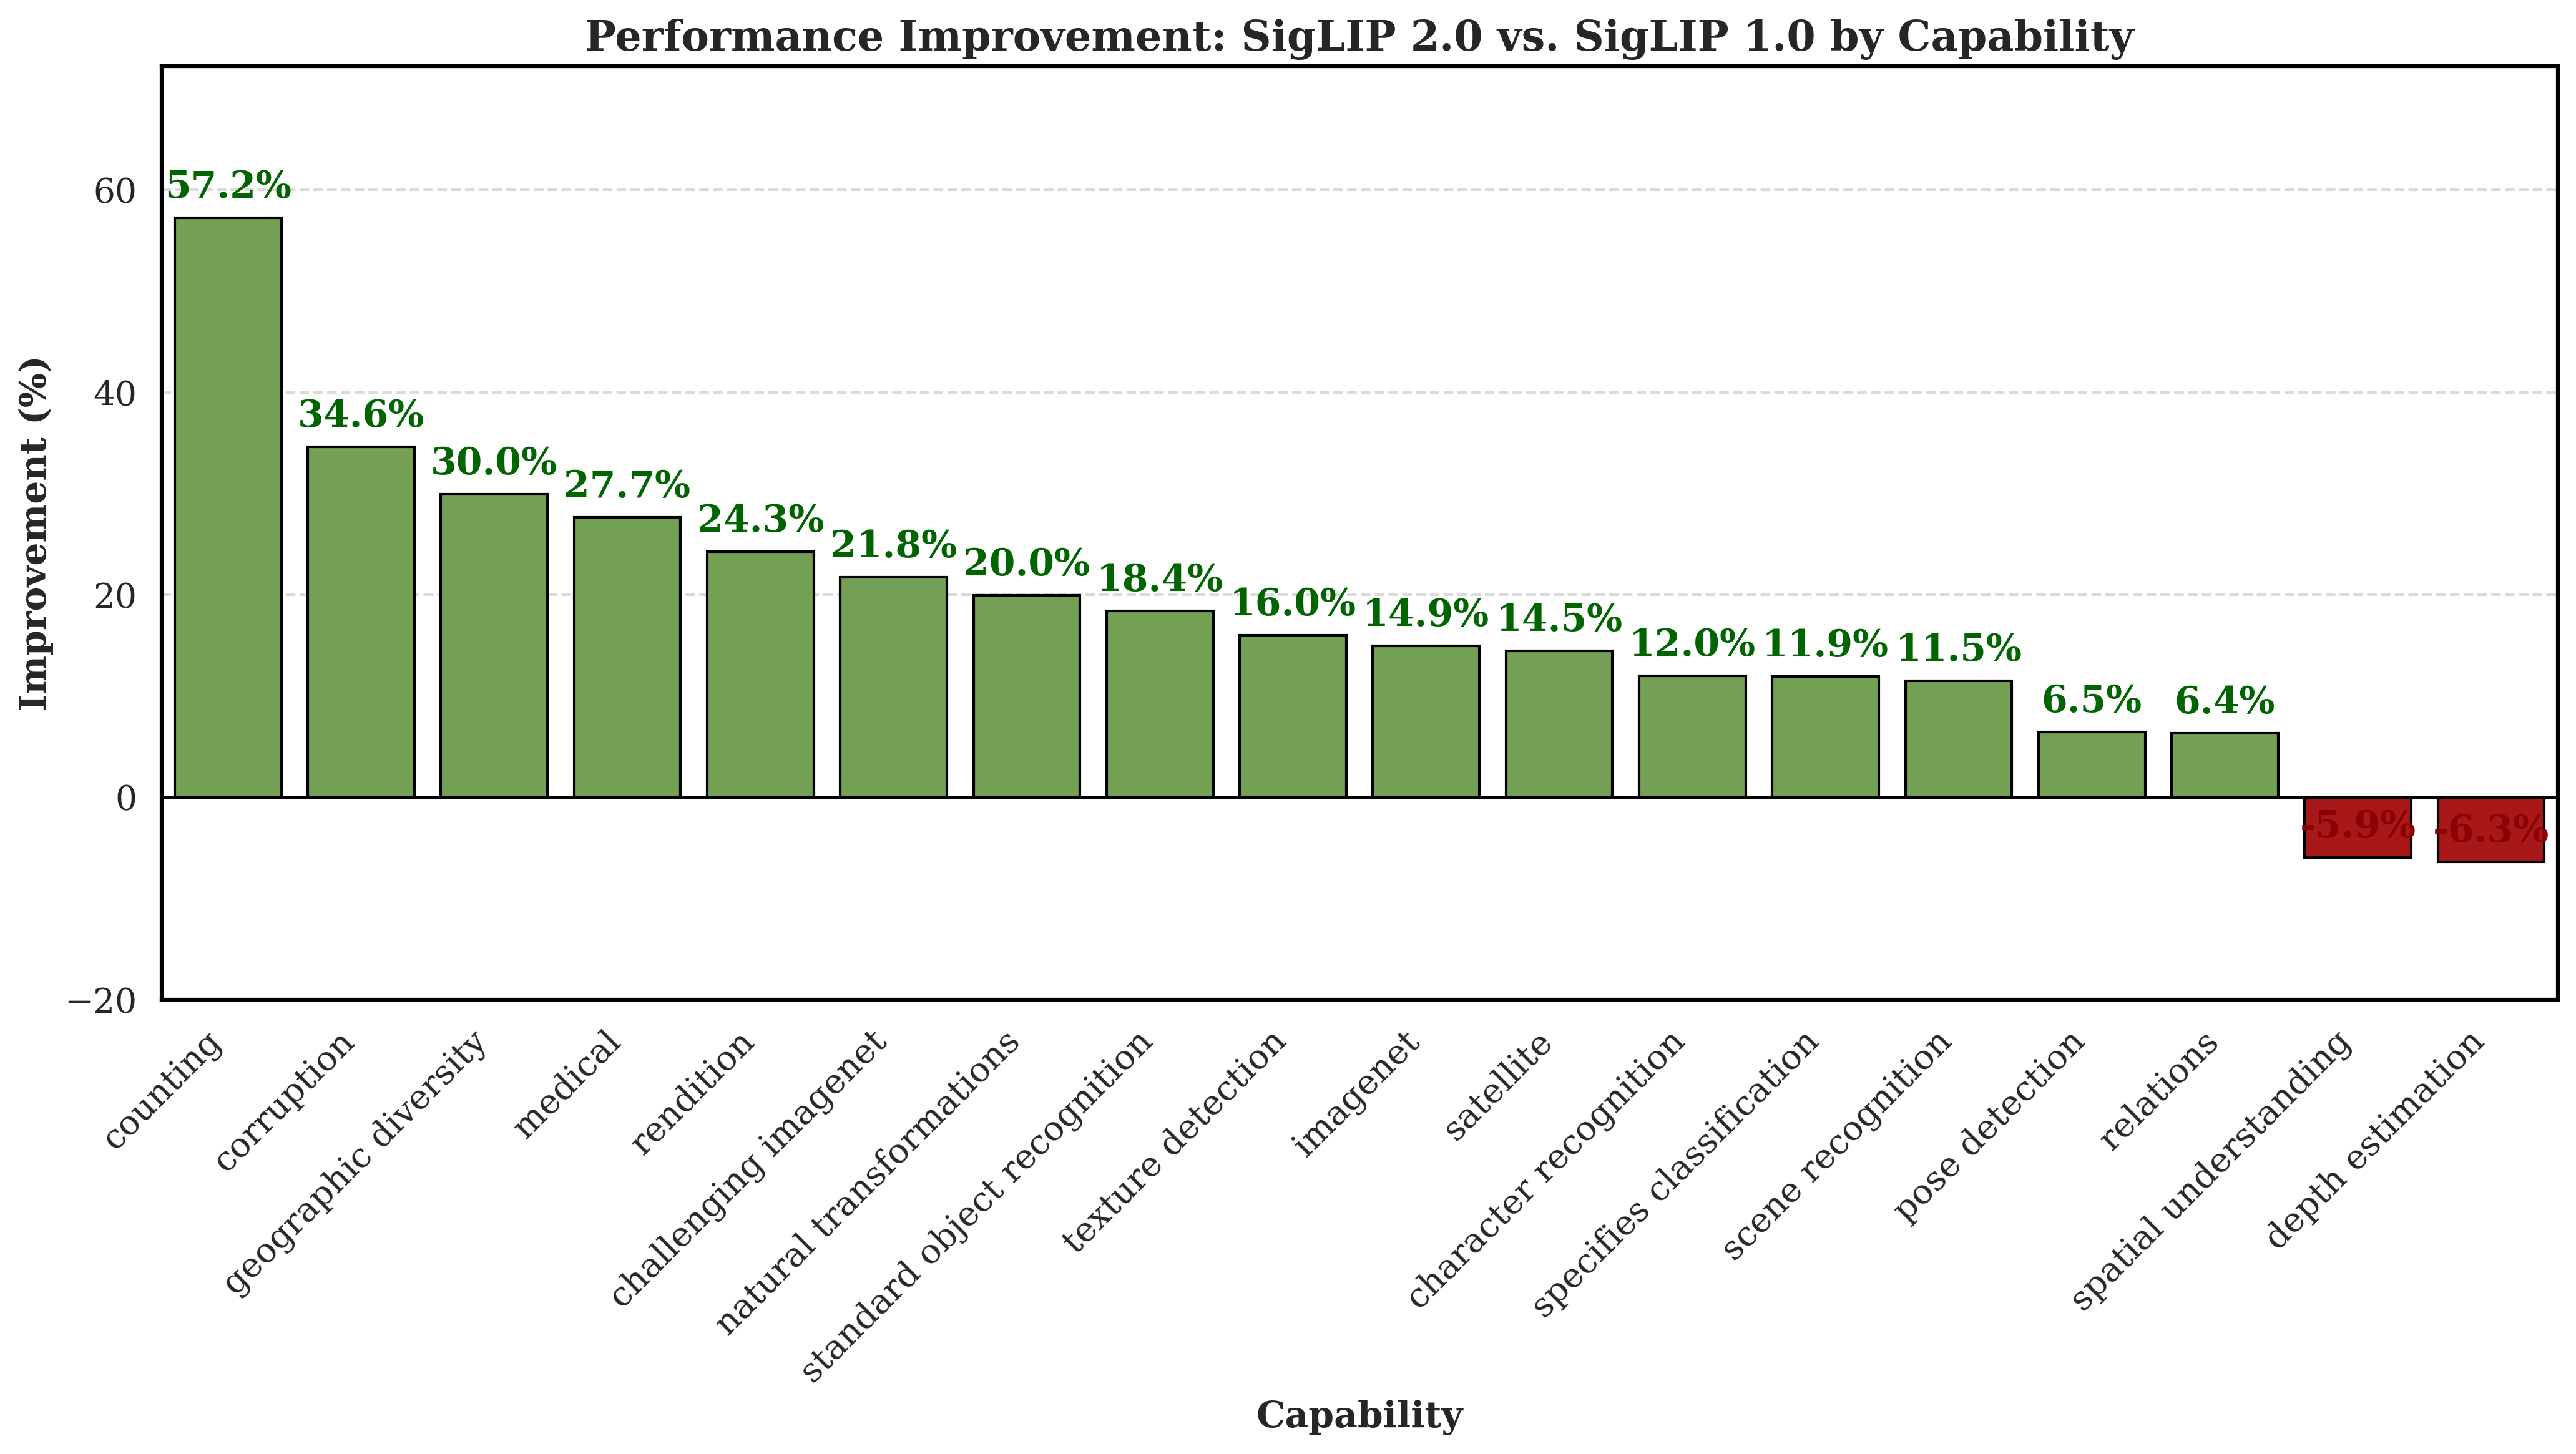

In [9]:
from unibench.common_utils.utils import get_benchmark_mappings
benchmark_mappings = get_benchmark_mappings("capability")
results["capability"] = results["benchmark_name"].map(benchmark_mappings)

# Get unique capabilities
capabilities = results.capability.unique()
capabilities = sorted(capabilities)  # Sort for consistent order

# Group results by model_name, capability and calculate mean performance
capability_performance = results.groupby(["model_name", "capability"]).correctness.mean() * 100
capability_sem = results.groupby(["model_name", "capability"]).correctness.sem() * 100

# Create a DataFrame with the performance data
performance_by_capability = capability_performance.reset_index().pivot(index='model_name', columns='capability', values='correctness')
performance_by_capability = performance_by_capability.reset_index()

# Add model type column
performance_by_capability['type'] = performance_by_capability['model_name'].apply(lambda x: 'SigLIP 1.0' if not x.startswith('siglip2') else 'SigLIP 2.0')

# Set up the figure with subplots
import math
num_capabilities = len(capabilities)
cols = 3  # Adjust as needed
rows = math.ceil(num_capabilities / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows), dpi=300)
axes = axes.flatten()  # Flatten for easy indexing

# Set style
sns.set(style="whitegrid", font_scale=1.2)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['axes.edgecolor'] = 'black'

# Iterate through each capability
for i, capability in enumerate(capabilities):
    # Skip if capability is missing in the data
    if capability not in performance_by_capability.columns:
        axes[i].axis('off')
        continue
    
    # Prepare data for this capability
    data = performance_by_capability[['model_name', capability, 'type']].copy()
    data.columns = ['model_name', 'performance', 'type']
    data = data.dropna()
    
    # Calculate averages for each type
    siglip1_avg = data[data['type'] == 'SigLIP 1.0']['performance'].mean()
    siglip2_avg = data[data['type'] == 'SigLIP 2.0']['performance'].mean()
    improvement = ((siglip2_avg - siglip1_avg) / siglip1_avg * 100) if siglip1_avg > 0 else 0
    
    # Sort data for this plot
    data = data.sort_values('performance', ascending=False)
    
    # Create barplot
    ax = axes[i]
    sns.barplot(
        x='model_name', 
        y='performance', 
        hue='type',
        data=data,
        palette={'SigLIP 1.0': '#4472C4', 'SigLIP 2.0': '#70AD47'},
        edgecolor='black',
        linewidth=1,
        ax=ax
    )
    
    # Customize this subplot
    ax.set_title(f'{capability.capitalize()} Task Performance', fontweight='bold')
    ax.set_xlabel('Model Architecture')
    ax.set_ylabel(f'{capability.capitalize()} Score (%)')
    
    # Format x-axis labels
    labels = [' '.join(x.split('_')[1:]) for x in data['model_name']]
    ax.set_xticklabels(labels, rotation=45, ha='right')
    
    # Add horizontal lines for average performance
    ax.axhline(y=siglip1_avg, color='#4472C4', linestyle='--', alpha=0.7, linewidth=1.5)
    ax.axhline(y=siglip2_avg, color='#70AD47', linestyle='--', alpha=0.7, linewidth=1.5)
    
    # Add improvement annotation
    textstr = f"Average Performance:\nSigLIP 1.0: {siglip1_avg:.1f}%\nSigLIP 2.0: {siglip2_avg:.1f}%\nImprovement: {improvement:.1f}%"
    props = dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='gray')
    ax.annotate(textstr, xy=(0.02, 0.02), xycoords='axes fraction', bbox=props, fontsize=10)
    
    # Legend for first plot only
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, title='Model Family', frameon=True, edgecolor='black')
    else:
        ax.get_legend().remove()  # Remove redundant legends

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Also create a summary plot showing the average improvement by capability
plt.figure(figsize=(14, 8), dpi=300)

# Calculate average performance for each capability and model family
avg_by_capability = {}
for capability in capabilities:
    if capability in performance_by_capability.columns:
        siglip1_avg = performance_by_capability[performance_by_capability['type'] == 'SigLIP 1.0'][capability].mean()
        siglip2_avg = performance_by_capability[performance_by_capability['type'] == 'SigLIP 2.0'][capability].mean()
        improvement = ((siglip2_avg - siglip1_avg) / siglip1_avg * 100) if siglip1_avg > 0 else 0
        avg_by_capability[capability] = {
            'siglip1': siglip1_avg,
            'siglip2': siglip2_avg,
            'improvement': improvement
        }

# Create dataframe for the summary plot
summary_data = pd.DataFrame(avg_by_capability).T.reset_index()
summary_data.columns = ['capability', 'siglip1', 'siglip2', 'improvement']
summary_data = summary_data.sort_values('improvement', ascending=False)

# Create the barplot for improvement percentage
colors = ['#70AD47' if x > 0 else '#C00000' for x in summary_data['improvement']]
ax = sns.barplot(x='capability', y='improvement', data=summary_data, palette=colors, edgecolor='black', linewidth=1)

# Add percentage labels on top of each bar
for i, v in enumerate(summary_data['improvement']):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold', 
             color='darkgreen' if v > 0 else 'darkred')

# Add horizontal line at 0% for reference
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)

# Customize the plot
plt.xlabel('Capability', fontweight='bold', fontsize=14)
plt.ylabel('Improvement (%)', fontweight='bold', fontsize=14)
plt.title('Performance Improvement: SigLIP 2.0 vs. SigLIP 1.0 by Capability', fontweight='bold', fontsize=16)
plt.xticks(rotation=45, ha='right')

# Set y-axis limits to accommodate the labels
plt.ylim(-20, summary_data['improvement'].max() + 15)

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

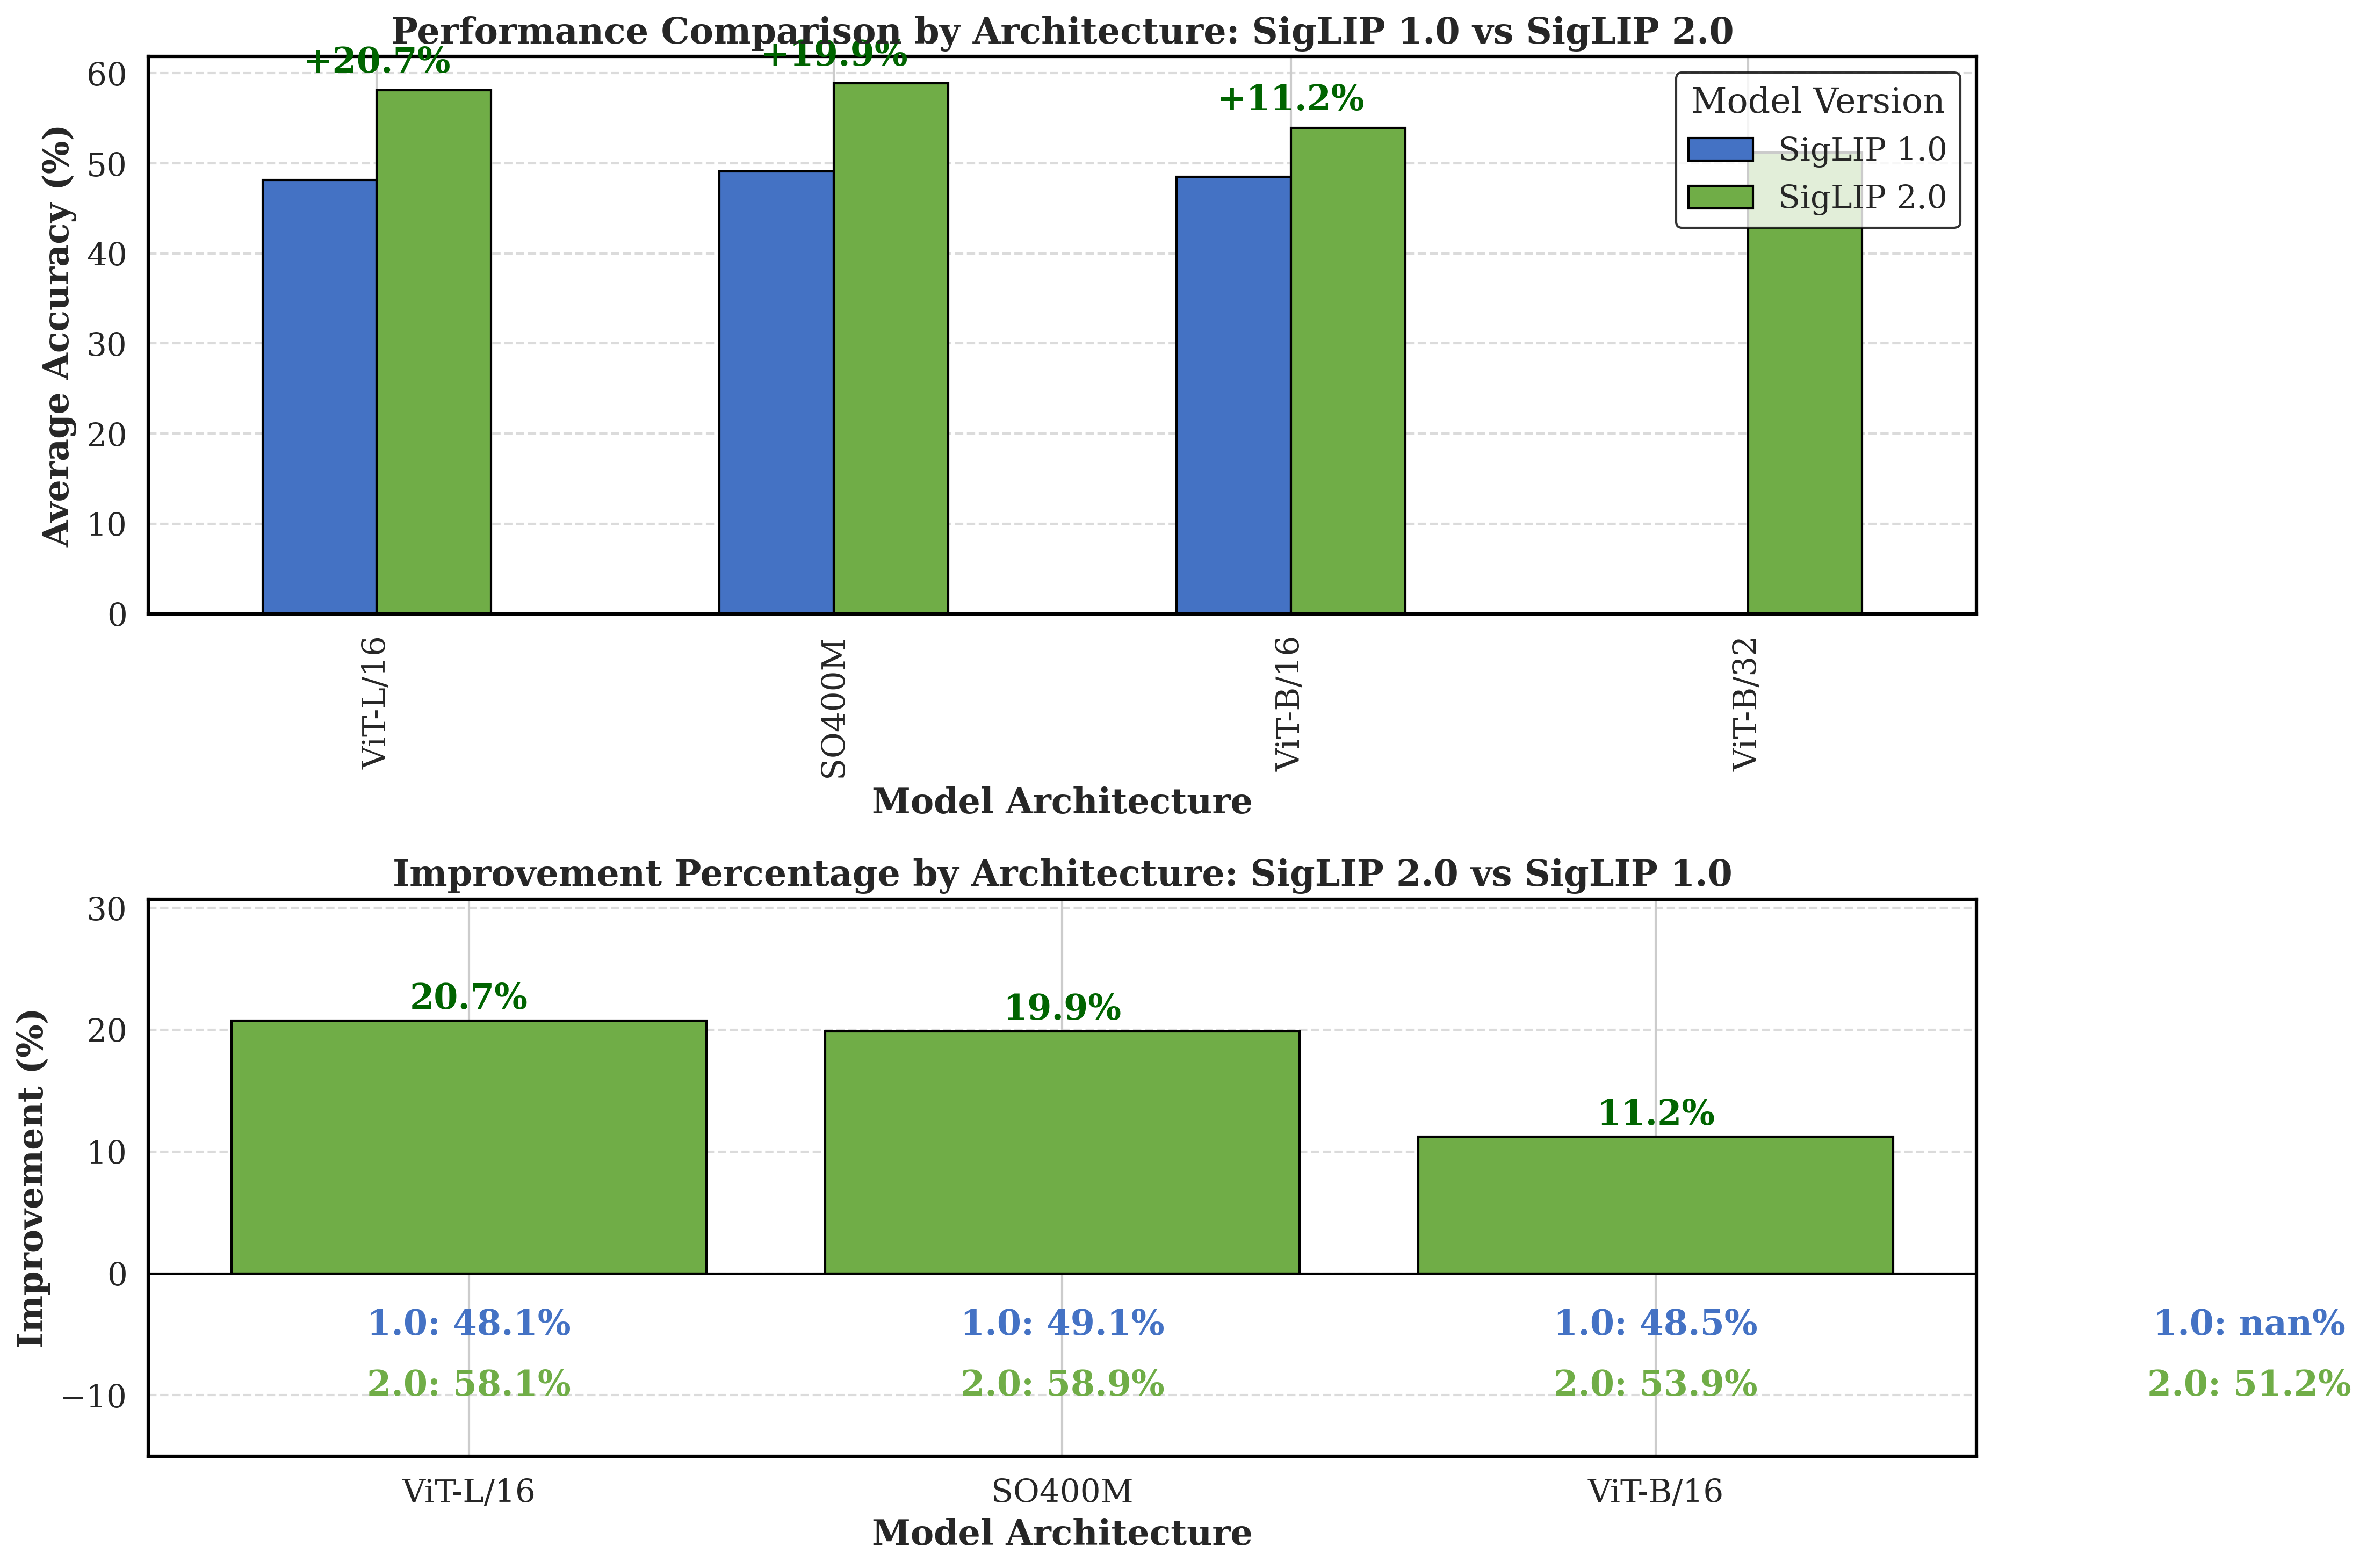

In [7]:
# Create figure to analyze architecture-specific improvements
plt.figure(figsize=(15, 10), dpi=300)
sns.set(style="whitegrid", font_scale=1.3)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['axes.edgecolor'] = 'black'

# Extract architecture information from model names
def extract_architecture(model_name):
    if 'so400' in model_name:
        return 'SO400M'
    elif 'vitB16' in model_name:
        return 'ViT-B/16'
    elif 'vitL16' in model_name:
        return 'ViT-L/16'
    elif 'vitB32' in model_name:
        return 'ViT-B/32'
    else:
        return 'Other'

# Add architecture column to performance data
model_data['architecture'] = model_data['model_name'].apply(extract_architecture)

# Group by architecture and type, then calculate mean performance
arch_performance = model_data.groupby(['architecture', 'type'])['performance'].mean().reset_index()
arch_performance = arch_performance.pivot(index='architecture', columns='type', values='performance')
arch_performance['improvement'] = ((arch_performance['SigLIP 2.0'] - arch_performance['SigLIP 1.0']) / 
                                   arch_performance['SigLIP 1.0'] * 100)

# Sort by improvement for display
arch_performance = arch_performance.sort_values('improvement', ascending=False)

# Create the grouped bar chart for performance comparison
ax = plt.subplot(2, 1, 1)
arch_performance[['SigLIP 1.0', 'SigLIP 2.0']].plot(kind='bar', figsize=(15, 10), 
                                                    color=['#4472C4', '#70AD47'], 
                                                    edgecolor='black', linewidth=1, ax=ax)

# Add improvement percentages above bars
for i, arch in enumerate(arch_performance.index):
    improvement = arch_performance.loc[arch, 'improvement']
    plt.text(i, max(arch_performance.loc[arch, 'SigLIP 1.0'], arch_performance.loc[arch, 'SigLIP 2.0']) + 2, 
             f"+{improvement:.1f}%", ha='center', fontweight='bold', 
             color='darkgreen' if improvement > 0 else 'darkred')

# Customize plot
plt.title('Performance Comparison by Architecture: SigLIP 1.0 vs SigLIP 2.0', fontweight='bold', fontsize=16)
plt.xlabel('Model Architecture', fontweight='bold')
plt.ylabel('Average Accuracy (%)', fontweight='bold')
plt.legend(title='Model Version', frameon=True, edgecolor='black')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add subplot showing improvement percentage by architecture
plt.subplot(2, 1, 2)
bars = plt.bar(arch_performance.index, arch_performance['improvement'], 
               color=['#70AD47' if x > 0 else '#C00000' for x in arch_performance['improvement']], 
               edgecolor='black', linewidth=1)

# Add value labels on top of each bar
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{arch_performance['improvement'].iloc[i]:.1f}%", ha='center', 
             fontweight='bold', color='darkgreen' if arch_performance['improvement'].iloc[i] > 0 else 'darkred')

# Add base performance values below bars
for i, arch in enumerate(arch_performance.index):
    plt.text(i, -5, f"1.0: {arch_performance.loc[arch, 'SigLIP 1.0']:.1f}%", ha='center', color='#4472C4', fontweight='bold')
    plt.text(i, -10, f"2.0: {arch_performance.loc[arch, 'SigLIP 2.0']:.1f}%", ha='center', color='#70AD47', fontweight='bold')

# Customize subplot
plt.title('Improvement Percentage by Architecture: SigLIP 2.0 vs SigLIP 1.0', fontweight='bold', fontsize=16)
plt.xlabel('Model Architecture', fontweight='bold')
plt.ylabel('Improvement (%)', fontweight='bold')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(-15, arch_performance['improvement'].max() + 10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2871713/3870551027.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')


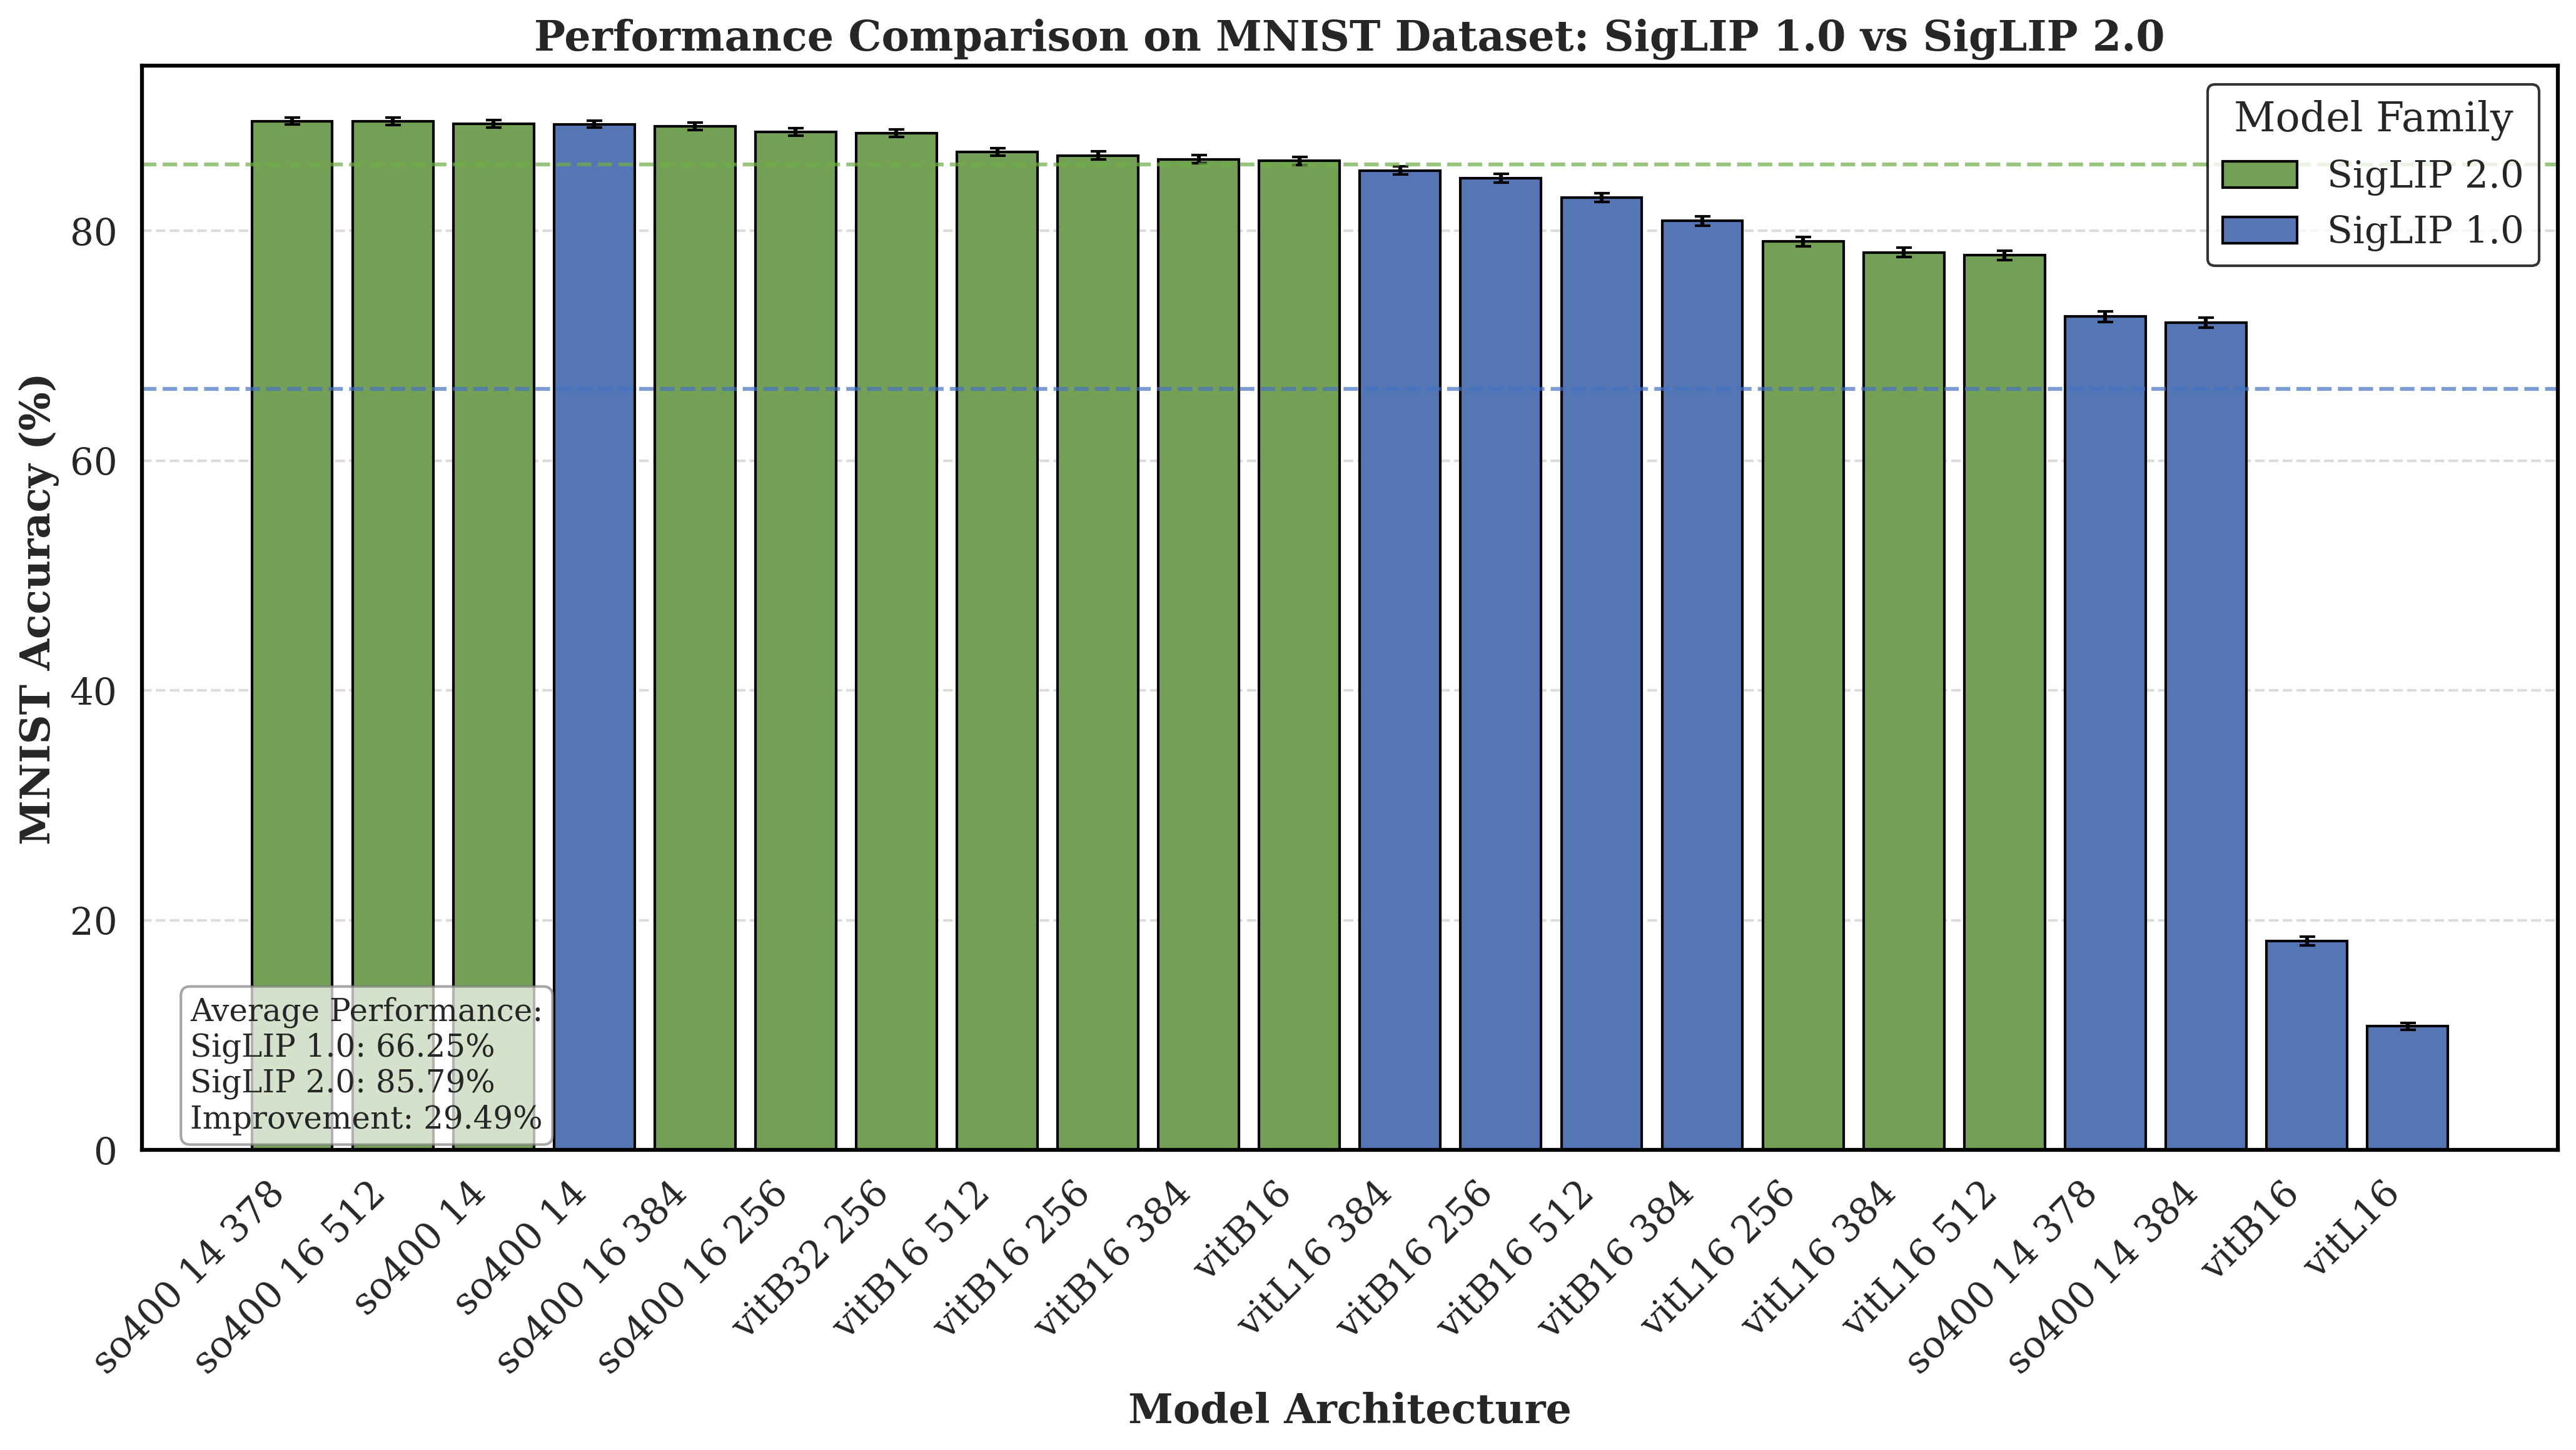

In [ ]:
# Extract MNIST performance for all models
mnist_results = results[results['benchmark_name'] == 'mnist'].groupby('model_name').correctness.mean() * 100
mnist_sem = results[results['benchmark_name'] == 'mnist'].groupby('model_name').correctness.sem() * 100

# Create a DataFrame for plotting
mnist_df = pd.DataFrame({
    'model_name': mnist_results.index,
    'performance': mnist_results.values,
    'sem': mnist_sem.values
})

# Add model type column
mnist_df['type'] = mnist_df['model_name'].apply(lambda x: 'SigLIP 1.0' if not x.startswith('siglip2') else 'SigLIP 2.0')

# Sort by performance
mnist_df = mnist_df.sort_values('performance', ascending=False)

# Calculate average performance by model type
siglip1_avg = mnist_df[mnist_df['type'] == 'SigLIP 1.0']['performance'].mean()
siglip2_avg = mnist_df[mnist_df['type'] == 'SigLIP 2.0']['performance'].mean()
improvement = ((siglip2_avg - siglip1_avg) / siglip1_avg * 100) if siglip1_avg > 0 else 0

# Create the plot
plt.figure(figsize=(14, 8), dpi=300)
sns.set(style="whitegrid", font_scale=1.3)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['axes.edgecolor'] = 'black'

# Create barplot with error bars
ax = sns.barplot(
    x='model_name', 
    y='performance', 
    hue='type',
    data=mnist_df,
    palette={'SigLIP 1.0': '#4472C4', 'SigLIP 2.0': '#70AD47'},
    edgecolor='black',
    linewidth=1
)

# Add error bars
for i, row in enumerate(mnist_df.itertuples()):
    plt.errorbar(i, row.performance, yerr=row.sem, fmt='none', color='black', capsize=3, elinewidth=1.5)

# Format x-axis labels
labels = [' '.join(x.split('_')[1:]) for x in mnist_df['model_name']]
ax.set_xticklabels(labels, rotation=45, ha='right')

# Add horizontal lines for average performance
plt.axhline(y=siglip1_avg, color='#4472C4', linestyle='--', alpha=0.7, linewidth=1.5)
plt.axhline(y=siglip2_avg, color='#70AD47', linestyle='--', alpha=0.7, linewidth=1.5)

# Customize the plot
plt.xlabel('Model Architecture', fontweight='bold')
plt.ylabel('MNIST Accuracy (%)', fontweight='bold')
plt.title('Performance Comparison on MNIST Dataset: SigLIP 1.0 vs SigLIP 2.0', fontweight='bold', fontsize=16)

# Add information about average performance
textstr = f"Average Performance:\nSigLIP 1.0: {siglip1_avg:.2f}%\nSigLIP 2.0: {siglip2_avg:.2f}%\nImprovement: {improvement:.2f}%"
props = dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='gray')
plt.annotate(textstr, xy=(0.02, 0.02), xycoords='axes fraction', bbox=props, fontsize=12)

# Improve legend
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, title='Model Family', frameon=True, edgecolor='black')

# Add grid and adjust layout
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()